##### załadowane danych i wstępne oczyszczenie danych

In [3]:
from matplotlib.ticker import PercentFormatter

In [ ]:
import ast 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt  
from datasets import load_dataset

def clean_list(skill_list):
    if pd.notna(skill_list):
        return ast.literal_eval(skill_list)

#loading data
datasets = load_dataset('lukebarousse/data_jobs')
df = datasets['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df.job_posted_date)
df['job_skills'] = df['job_skills'].apply(clean_list)

oferty tylko w stanach zjednoczonych i analityka danych

In [5]:
df_us_da = df[(df['job_country'] == 'United States') & (df['job_title_short'] == 'Data Analyst')].copy()
df_us_da = df_us_da.dropna(subset=['salary_year_avg'])

grupowanie umiejętności i zmiana na procenty

In [6]:
df_sklills = df_us_da.explode('job_skills')
skills_stats = df_sklills.groupby('job_skills').agg(
    skill_count=('job_skills', 'size'),
    skill_median=('salary_year_avg', 'median')
)

total_jobs = len(df_us_da)
skills_stats['skill_percentage'] = (skills_stats['skill_count'] / total_jobs) * 100
skills_stats = skills_stats.sort_values(by='skill_percentage', ascending=False)


In [7]:
number_skills = 10
top_skills = skills_stats.head(number_skills)

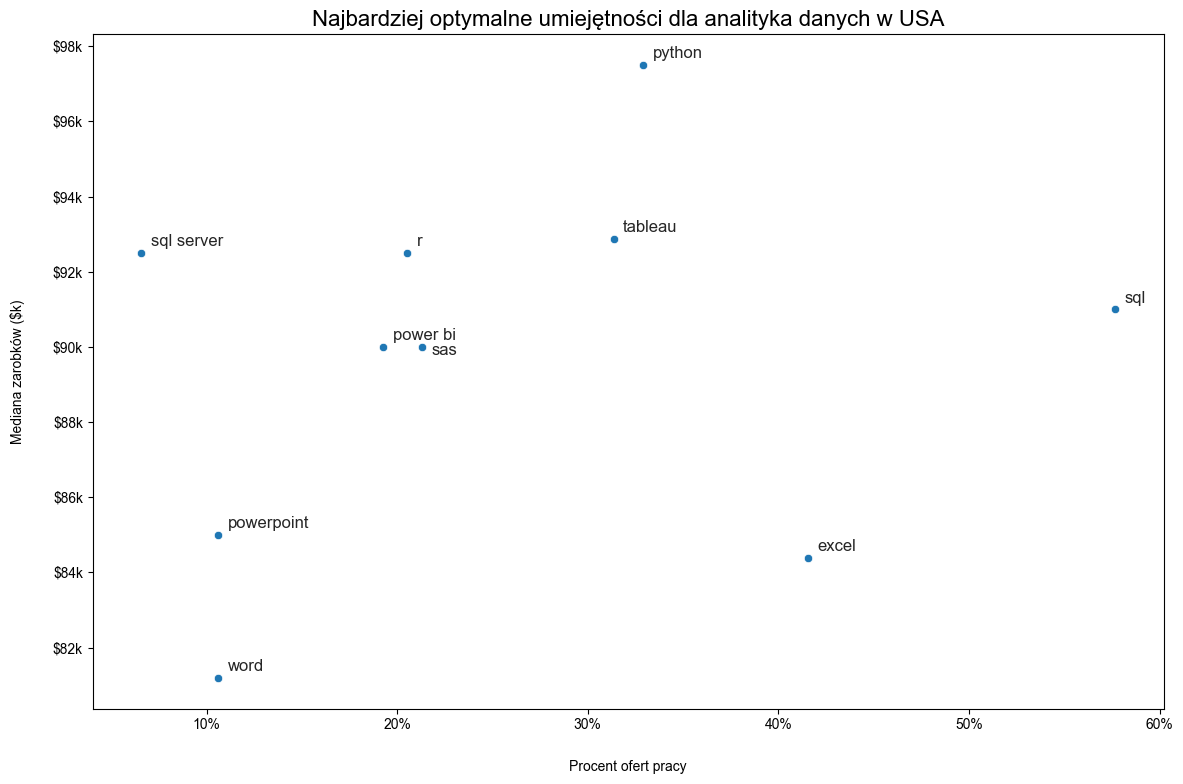

In [8]:
fig, ax = plt.subplots(figsize=(12, 8))
sns.set_theme(style="ticks")
sns.scatterplot(data=top_skills, x='skill_percentage', y='skill_median', legend=False)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}k'))
ax.xaxis.set_major_formatter(PercentFormatter(decimals=0))
plt.title('Najbardziej optymalne umiejętności dla analityka danych w USA', fontsize=16)
plt.xlabel('Procent ofert pracy', labelpad=20)
plt.ylabel('Mediana zarobków ($k)', labelpad=20)

for i, text in enumerate(top_skills.index):
    va = 'bottom'
    if text == 'sas': 
        va='top'
    plt.text(
        top_skills['skill_percentage'].iloc[i]+0.5,
        top_skills['skill_median'].iloc[i] + 100,
        text, fontsize=12,
        ha='left',
        va = va        
    )

plt.tight_layout()
plt.show()

Podział umiejętności na grupy związane z technologią 

In [9]:
df_technology = df['job_type_skills'].copy()

#usunięcie duplikatów i wartości null, a następnie konwersja do DataFrame
df_technology = df_technology.drop_duplicates().dropna().to_frame()

#czyszczenie danych w kolumnie 'job_type_skills, uzyskujemy typ danych dict'
df_technology['job_type_skills'] = df_technology['job_type_skills'].apply(clean_list)



In [10]:
#tworzenie słownika, gdzie kluczem jest technologia, a wartością zbiór umiejętności
technology_dict = {}

for row in df_technology.iloc[:, 0]:
    for key, values in row.items():
        if key not in technology_dict:
            technology_dict[key] = set()
        technology_dict[key].update(values)


In [11]:
#dict do DataFrame, gdzie każda technologia jest powiązana z umiejętnościami
df_technology = pd.DataFrame(list(technology_dict.items()), columns=['technology', 'skills']) 

#rozbicie listy umiejętności na osobne wiersze
df_technology = df_technology.explode('skills')


In [12]:
df_plot = top_skills.merge(df_technology, left_on='job_skills', right_on='skills')

modyfikacja wykresu

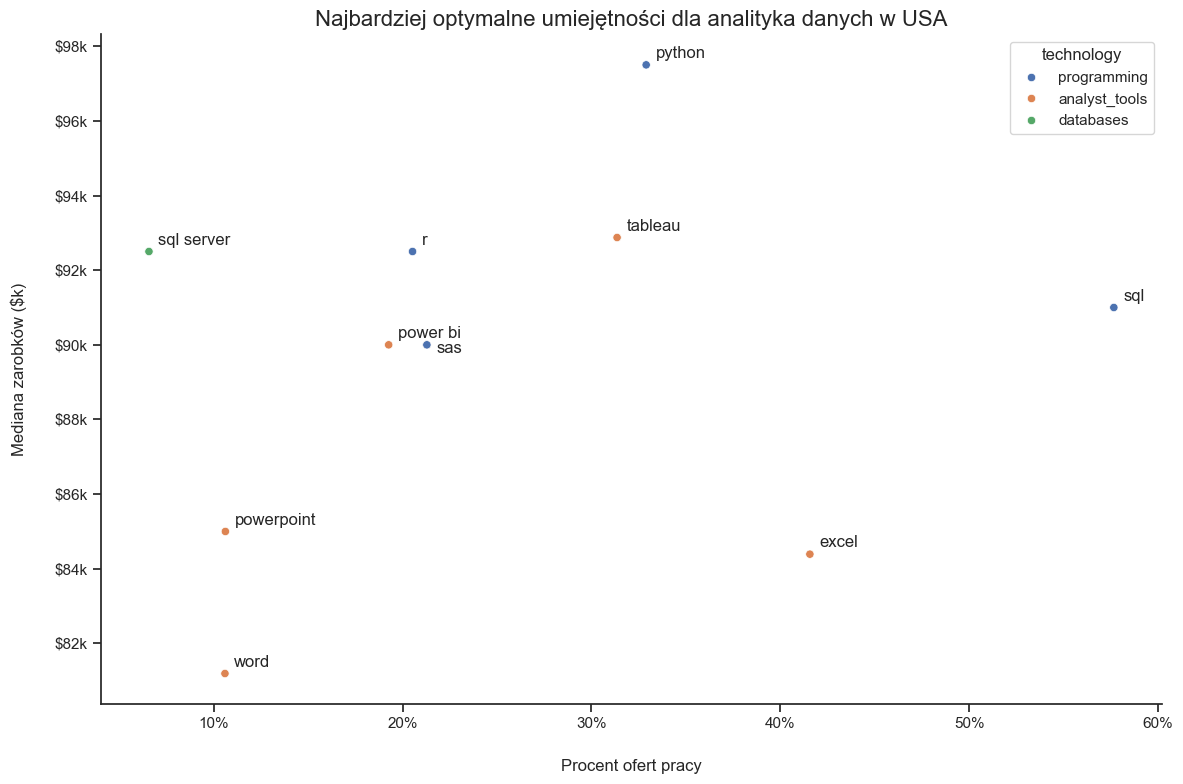

In [13]:
fig, ax = plt.subplots(figsize=(12, 8))
sns.set_theme(style="ticks")
sns.despine()
sns.scatterplot(
    data=df_plot,
    x='skill_percentage',
    y='skill_median',
    hue='technology'
)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}k'))
ax.xaxis.set_major_formatter(PercentFormatter(decimals=0))
plt.title('Najbardziej optymalne umiejętności dla analityka danych w USA', fontsize=16)
plt.xlabel('Procent ofert pracy', labelpad=20)
plt.ylabel('Mediana zarobków ($k)', labelpad=20)

for i, text in enumerate(top_skills.index):
    va = 'bottom'
    if text == 'sas': 
        va='top'
    plt.text(
        top_skills['skill_percentage'].iloc[i]+0.5,
        top_skills['skill_median'].iloc[i] + 100,
        text, fontsize=12,
        ha='left',
        va = va        
    )

plt.tight_layout()
plt.show()